# Time Series Analysis with TuiML

This tutorial covers **time series analysis and forecasting** using TuiML's algorithms. Time series data is sequential data indexed by time, and forecasting involves predicting future values based on historical patterns.

## What You'll Learn

- **AR (Autoregressive)** — Predict using past values
- **MA (Moving Average)** — Predict using past errors
- **ARMA** — Combines AR and MA
- **ARIMA** — ARMA with differencing for non-stationary data
- **Exponential Smoothing** — Weighted averages of past observations
- **STL Decomposition** — Seasonal-Trend decomposition
- **Prophet** — Automatic forecasting with seasonality

## Setup

First, let's import the necessary modules and create some time series data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import time series algorithms
from tuiml.algorithms.timeseries import (
    AR,
    MA,
    ARMA,
    ARIMA,
    ExponentialSmoothing,
    STLDecomposition,
    Prophet
)

# Set random seed for reproducibility
np.random.seed(42)

print("TuiML Time Series Algorithms:")
print("  - AR (Autoregressive)")
print("  - MA (Moving Average)")
print("  - ARMA (AR + MA)")
print("  - ARIMA (ARMA + Differencing)")
print("  - ExponentialSmoothing")
print("  - STLDecomposition")
print("  - Prophet")

TuiML Time Series Algorithms:
  - AR (Autoregressive)
  - MA (Moving Average)
  - ARMA (AR + MA)
  - ARIMA (ARMA + Differencing)
  - ExponentialSmoothing
  - STLDecomposition
  - Prophet


## Creating Sample Time Series Data

Let's create different types of time series to demonstrate various algorithms.

In [2]:
# Generate time index
n_points = 200
t = np.arange(n_points)

# 1. Stationary series (for AR/MA/ARMA)
noise = np.random.randn(n_points) * 0.5
y_stationary = np.zeros(n_points)
for i in range(2, n_points):
    y_stationary[i] = 0.6 * y_stationary[i-1] - 0.2 * y_stationary[i-2] + noise[i]

# 2. Non-stationary series with trend (for ARIMA)
trend = 0.05 * t
y_trending = y_stationary + trend

# 3. Seasonal series (for STL/Prophet)
seasonality = 3 * np.sin(2 * np.pi * t / 12)  # Monthly seasonality
y_seasonal = y_stationary + trend + seasonality

print(f"Created {n_points} data points for:")
print(f"  - Stationary series")
print(f"  - Trending series")
print(f"  - Seasonal series")

Created 200 data points for:
  - Stationary series
  - Trending series
  - Seasonal series


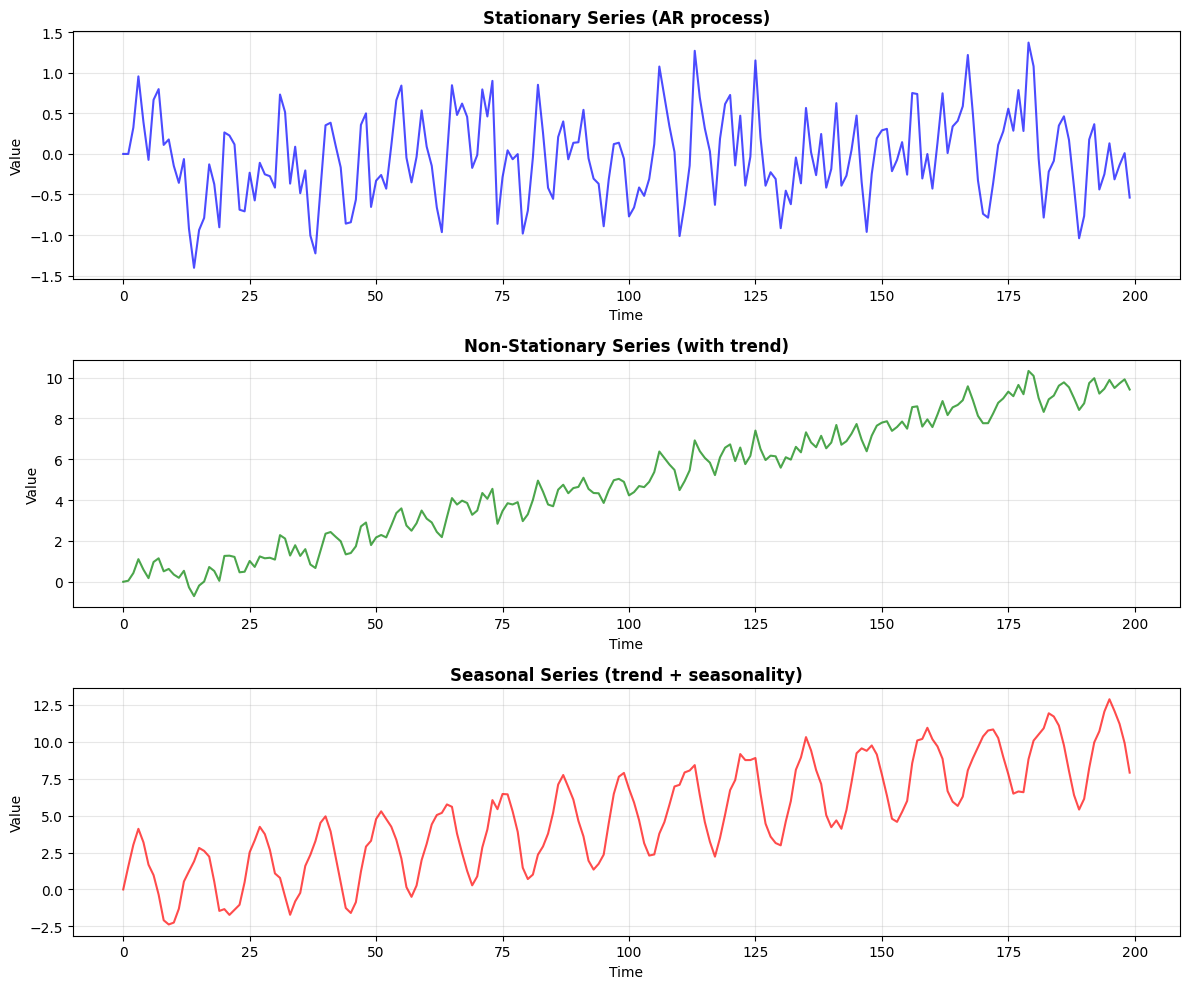

In [3]:
# Visualize the different series
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(t, y_stationary, 'b-', alpha=0.7)
axes[0].set_title('Stationary Series (AR process)', fontweight='bold')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, y_trending, 'g-', alpha=0.7)
axes[1].set_title('Non-Stationary Series (with trend)', fontweight='bold')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, y_seasonal, 'r-', alpha=0.7)
axes[2].set_title('Seasonal Series (trend + seasonality)', fontweight='bold')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Value')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1. AR (Autoregressive) Model

**AR(p)** predicts the current value based on `p` previous values:

$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + ... + \phi_p y_{t-p} + \epsilon_t$$

where:
- $\phi_i$ are the autoregressive coefficients
- $\epsilon_t$ is white noise

**Best for:** Data where current values depend on recent past values

In [4]:
# Split data into train/test
train_size = 180
y_train = y_stationary[:train_size]
y_test = y_stationary[train_size:]

# Fit AR model
ar_model = AR(order=2)  # AR(2) - use 2 lags
ar_model.fit(y_train)

# Forecast
forecast_ar = ar_model.predict(steps=len(y_test))

print(f"AR(2) Model:")
print(f"  Coefficients: {ar_model.ar_params_}")
print(f"  Forecast length: {len(forecast_ar)}")

AR(2) Model:
  Coefficients: [ 0.51178959 -0.1766365 ]
  Forecast length: 20


In [5]:
# Evaluate AR model
from tuiml.evaluation import mean_squared_error, mean_absolute_error

mse_ar = mean_squared_error(y_test, forecast_ar)
mae_ar = mean_absolute_error(y_test, forecast_ar)
rmse_ar = np.sqrt(mse_ar)

print(f"AR(2) Performance:")
print(f"  MSE: {mse_ar:.4f}")
print(f"  RMSE: {rmse_ar:.4f}")
print(f"  MAE: {mae_ar:.4f}")

AR(2) Performance:
  MSE: 0.1814
  RMSE: 0.4260
  MAE: 0.3478


## 2. MA (Moving Average) Model

**MA(q)** predicts using past forecast errors:

$$y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + ... + \theta_q \epsilon_{t-q}$$

where:
- $\theta_i$ are the moving average coefficients
- $\epsilon_t$ are the error terms

**Best for:** Data where shocks (errors) have a lingering effect

In [6]:
# Fit MA model
ma_model = MA(order=2)  # MA(2)
ma_model.fit(y_train)

# Forecast
forecast_ma = ma_model.predict(steps=len(y_test))

mse_ma = mean_squared_error(y_test, forecast_ma)
rmse_ma = np.sqrt(mse_ma)

print(f"MA(2) Performance:")
print(f"  MSE: {mse_ma:.4f}")
print(f"  RMSE: {rmse_ma:.4f}")

MA(2) Performance:
  MSE: 0.2299
  RMSE: 0.4795


## 3. ARMA Model

**ARMA(p, q)** combines AR and MA:

$$y_t = c + \sum_{i=1}^{p} \phi_i y_{t-i} + \sum_{j=1}^{q} \theta_j \epsilon_{t-j} + \epsilon_t$$

**Best for:** Stationary data with both autoregressive and moving average components

In [7]:
# Fit ARMA model
arma_model = ARMA(order=(2, 1))  # ARMA(2, 1)
arma_model.fit(y_train)

# Forecast
forecast_arma = arma_model.predict(steps=len(y_test))

mse_arma = mean_squared_error(y_test, forecast_arma)
rmse_arma = np.sqrt(mse_arma)

print(f"ARMA(2,1) Performance:")
print(f"  AR coefficients: {arma_model.ar_params_}")
print(f"  MA coefficients: {arma_model.ma_params_}")
print(f"  RMSE: {rmse_arma:.4f}")

ARMA(2,1) Performance:
  AR coefficients: [-1.26150701e+06  7.98436630e+16]
  MA coefficients: [0.]
  RMSE: 0.4891


## 4. ARIMA Model

**ARIMA(p, d, q)** adds differencing to ARMA for non-stationary data:

- **p**: Number of autoregressive terms
- **d**: Number of differences needed for stationarity
- **q**: Number of moving average terms

**Best for:** Non-stationary data with trends

In [8]:
# Use trending data for ARIMA
y_train_trend = y_trending[:train_size]
y_test_trend = y_trending[train_size:]

# Fit ARIMA model with trend='c' to capture the drift in differenced data
arima_model = ARIMA(order=(1, 1, 0), trend='c', method='css')
arima_model.fit(y_train_trend)

# Forecast
forecast_arima = arima_model.predict(steps=len(y_test_trend))

mse_arima = mean_squared_error(y_test_trend, forecast_arima)
rmse_arima = np.sqrt(mse_arima)

print(f"ARIMA(1,1,0) for Trending Data:")
print(f"  RMSE: {rmse_arima:.4f}")

ARIMA(1,1,0) for Trending Data:
  RMSE: 1.4492


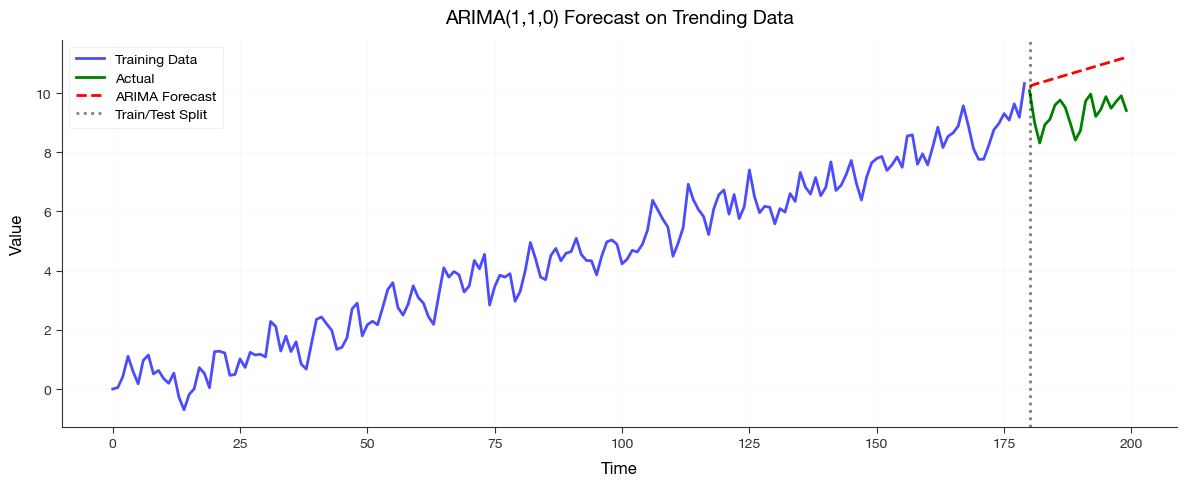

In [9]:
# Visualize ARIMA forecast
plt.figure(figsize=(12, 5))

t_train = t[:train_size]
t_test = t[train_size:]

plt.plot(t_train, y_train_trend, 'b-', label='Training Data', alpha=0.7)
plt.plot(t_test, y_test_trend, 'g-', label='Actual', linewidth=2)
plt.plot(t_test, forecast_arima, 'r--', label='ARIMA Forecast', linewidth=2)
plt.axvline(x=train_size, color='k', linestyle=':', alpha=0.5, label='Train/Test Split')

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('ARIMA(1,1,0) Forecast on Trending Data', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Exponential Smoothing

**Exponential Smoothing** assigns exponentially decreasing weights to past observations:

$$\hat{y}_{t+1} = \alpha y_t + (1-\alpha) \hat{y}_t$$

Types:
- **Simple (SES)**: Level only
- **Holt**: Level + Trend
- **Holt-Winters**: Level + Trend + Seasonality

**Best for:** Smooth forecasts, data with trend and/or seasonality

In [10]:
# Simple Exponential Smoothing
ses = ExponentialSmoothing(
    trend=None,
    seasonal=None,
    smoothing_level=0.3
)
ses.fit(y_train)
forecast_ses = ses.predict(steps=len(y_test))

rmse_ses = np.sqrt(mean_squared_error(y_test, forecast_ses))
print(f"Simple Exponential Smoothing:")
print(f"  RMSE: {rmse_ses:.4f}")

Simple Exponential Smoothing:
  RMSE: 0.9043


In [11]:
# Holt's Linear Trend (for trending data)
holt = ExponentialSmoothing(
    trend='add',           # Additive trend
    seasonal=None,
    smoothing_level=0.3,
    smoothing_trend=0.1
)
holt.fit(y_train_trend)
forecast_holt = holt.predict(steps=len(y_test_trend))

rmse_holt = np.sqrt(mean_squared_error(y_test_trend, forecast_holt))
print(f"Holt's Linear Trend:")
print(f"  RMSE: {rmse_holt:.4f}")

Holt's Linear Trend:
  RMSE: 1.4770


In [12]:
# Holt-Winters (for seasonal data)
y_train_seasonal = y_seasonal[:train_size]
y_test_seasonal = y_seasonal[train_size:]

hw = ExponentialSmoothing(
    trend='add',
    seasonal='add',
    seasonal_periods=12,    # Monthly seasonality
    smoothing_level=0.3,
    smoothing_trend=0.1,
    smoothing_seasonal=0.1
)
hw.fit(y_train_seasonal)
forecast_hw = hw.predict(steps=len(y_test_seasonal))

rmse_hw = np.sqrt(mean_squared_error(y_test_seasonal, forecast_hw))
print(f"Holt-Winters (Seasonal):")
print(f"  RMSE: {rmse_hw:.4f}")

Holt-Winters (Seasonal):
  RMSE: 1.3194


## 6. STL Decomposition

**STL (Seasonal and Trend decomposition using Loess)** decomposes a time series into:

$$y_t = T_t + S_t + R_t$$

where:
- $T_t$: Trend component
- $S_t$: Seasonal component
- $R_t$: Residual component

**Best for:** Understanding the structure of seasonal data

In [13]:
# Apply STL decomposition
stl = STLDecomposition(period=12)  # 12-point seasonality
stl.fit(y_seasonal)

# Get components
trend_component = stl.trend_
seasonal_component = stl.seasonal_
residual_component = stl.resid_

print(f"STL Decomposition:")
print(f"  Period: 12")
print(f"  Trend variance: {np.var(trend_component):.4f}")
print(f"  Seasonal variance: {np.var(seasonal_component):.4f}")
print(f"  Residual variance: {np.var(residual_component):.4f}")

STL Decomposition:
  Period: 12
  Trend variance: 0.0715
  Seasonal variance: 9.1125
  Residual variance: 1.4686


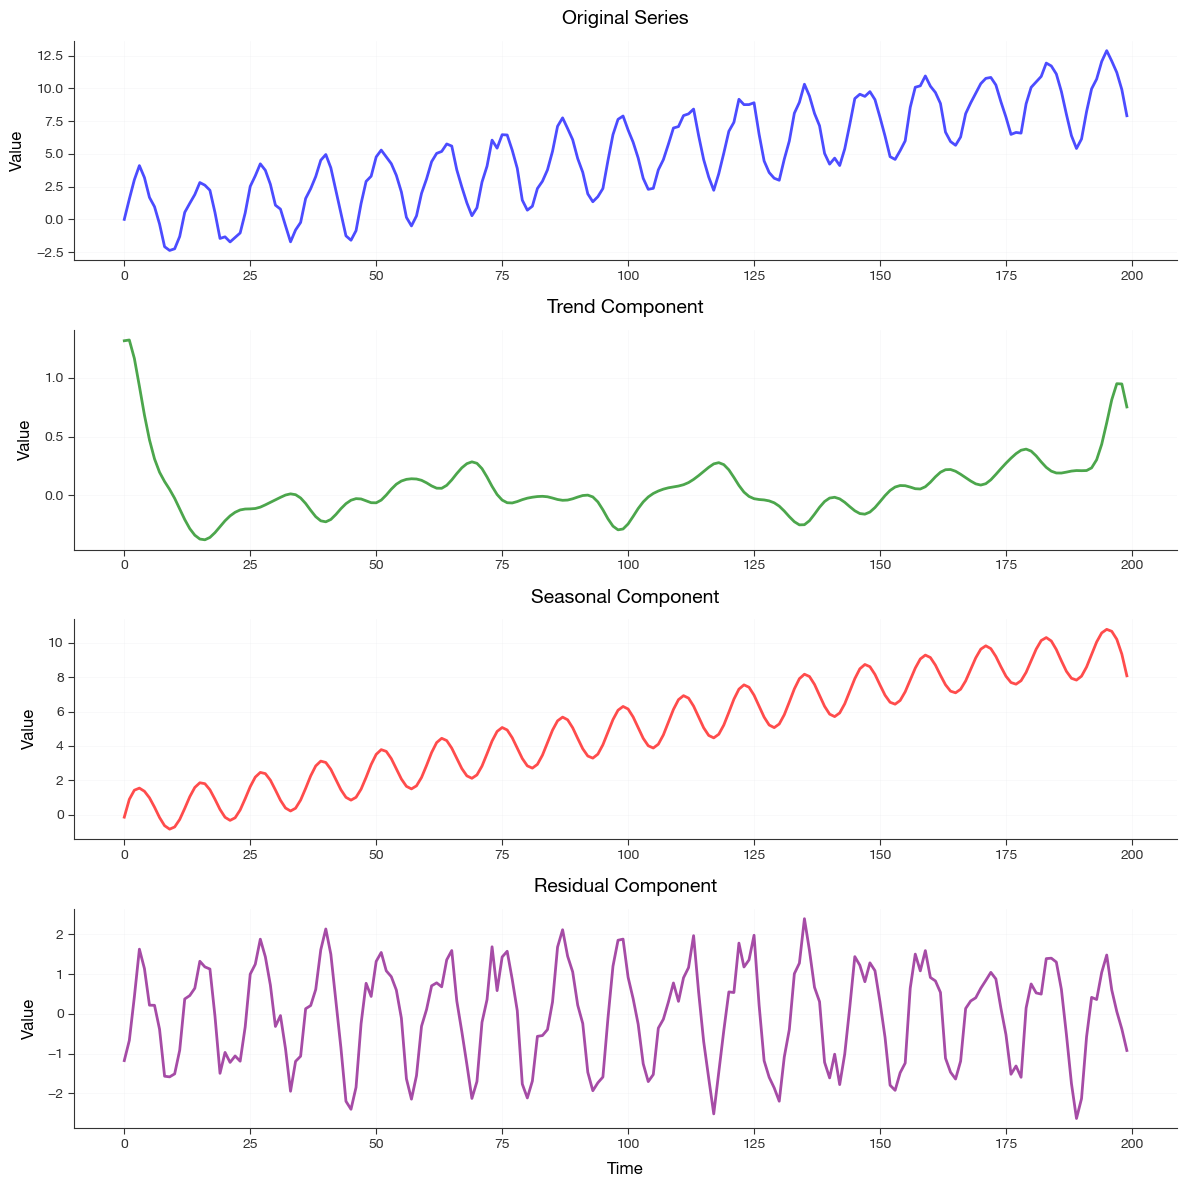

In [14]:
# Visualize STL decomposition
fig, axes = plt.subplots(4, 1, figsize=(12, 12))

axes[0].plot(t, y_seasonal, 'b-', alpha=0.7)
axes[0].set_title('Original Series', fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, trend_component, 'g-', alpha=0.7)
axes[1].set_title('Trend Component', fontweight='bold')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, seasonal_component, 'r-', alpha=0.7)
axes[2].set_title('Seasonal Component', fontweight='bold')
axes[2].set_ylabel('Value')
axes[2].grid(True, alpha=0.3)

axes[3].plot(t, residual_component, 'purple', alpha=0.7)
axes[3].set_title('Residual Component', fontweight='bold')
axes[3].set_xlabel('Time')
axes[3].set_ylabel('Value')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Prophet

**Prophet** is an automatic forecasting procedure that handles:
- Non-linear trends with changepoints
- Yearly, weekly, and daily seasonality
- Holiday effects

**Best for:** Business time series, automatic forecasting with minimal tuning

In [15]:
# Fit Prophet model
prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet.fit(y_train_seasonal)

# Forecast
forecast_prophet = prophet.predict(steps=len(y_test_seasonal))

rmse_prophet = np.sqrt(mean_squared_error(y_test_seasonal, forecast_prophet))
print(f"Prophet:")
print(f"  RMSE: {rmse_prophet:.4f}")

Prophet:
  RMSE: 2.1568


## Comparing All Models

Let's compare each model on its appropriate data type — stationary models on stationary data, ARIMA on trending data, and Holt-Winters on seasonal data.

In [16]:
# Compare models on their appropriate data types

# --- Stationary data: AR, MA, ARMA ---
stationary_models = {
    'AR(2)': AR(order=2),
    'MA(2)': MA(order=2),
    'ARMA(2,1)': ARMA(order=(2, 1)),
}

print("="*50)
print("STATIONARY DATA COMPARISON")
print("="*50)
print(f"{'Model':<18} {'RMSE':>10} {'MAE':>10}")
print("-"*50)

y_train_stat = y_stationary[:train_size]
y_test_stat = y_stationary[train_size:]

for name, model in stationary_models.items():
    model.fit(y_train_stat)
    forecast = model.predict(steps=len(y_test_stat))
    rmse = np.sqrt(mean_squared_error(y_test_stat, forecast))
    mae = mean_absolute_error(y_test_stat, forecast)
    print(f"{name:<18} {rmse:>10.4f} {mae:>10.4f}")

# --- Trending data: ARIMA ---
print("\n" + "="*50)
print("TRENDING DATA COMPARISON")
print("="*50)
print(f"{'Model':<18} {'RMSE':>10} {'MAE':>10}")
print("-"*50)

arima_cmp = ARIMA(order=(1, 1, 0), trend='c', method='css')
arima_cmp.fit(y_train_trend)
forecast = arima_cmp.predict(steps=len(y_test_trend))
rmse = np.sqrt(mean_squared_error(y_test_trend, forecast))
mae = mean_absolute_error(y_test_trend, forecast)
print(f"{'ARIMA(1,1,0)':<18} {rmse:>10.4f} {mae:>10.4f}")

# --- Seasonal data: Holt-Winters ---
print("\n" + "="*50)
print("SEASONAL DATA COMPARISON")
print("="*50)
print(f"{'Model':<18} {'RMSE':>10} {'MAE':>10}")
print("-"*50)

seasonal_models = {
    'Holt-Winters': ExponentialSmoothing(
        trend='add', seasonal='add', seasonal_periods=12,
        smoothing_level=0.3, smoothing_trend=0.1, smoothing_seasonal=0.1
    ),
}

forecasts = {}
results = {}

for name, model in seasonal_models.items():
    model.fit(y_train_seasonal)
    forecast = model.predict(steps=len(y_test_seasonal))
    rmse = np.sqrt(mean_squared_error(y_test_seasonal, forecast))
    mae = mean_absolute_error(y_test_seasonal, forecast)
    results[name] = {'RMSE': rmse, 'MAE': mae}
    forecasts[name] = forecast
    print(f"{name:<18} {rmse:>10.4f} {mae:>10.4f}")

print("="*50)

STATIONARY DATA COMPARISON
Model                    RMSE        MAE
--------------------------------------------------
AR(2)                  0.4260     0.3478
MA(2)                  0.4795     0.3796
ARMA(2,1)              0.4891     0.3844

TRENDING DATA COMPARISON
Model                    RMSE        MAE
--------------------------------------------------
ARIMA(1,1,0)           1.4492     1.3659

SEASONAL DATA COMPARISON
Model                    RMSE        MAE
--------------------------------------------------
Holt-Winters           1.3194     1.2070


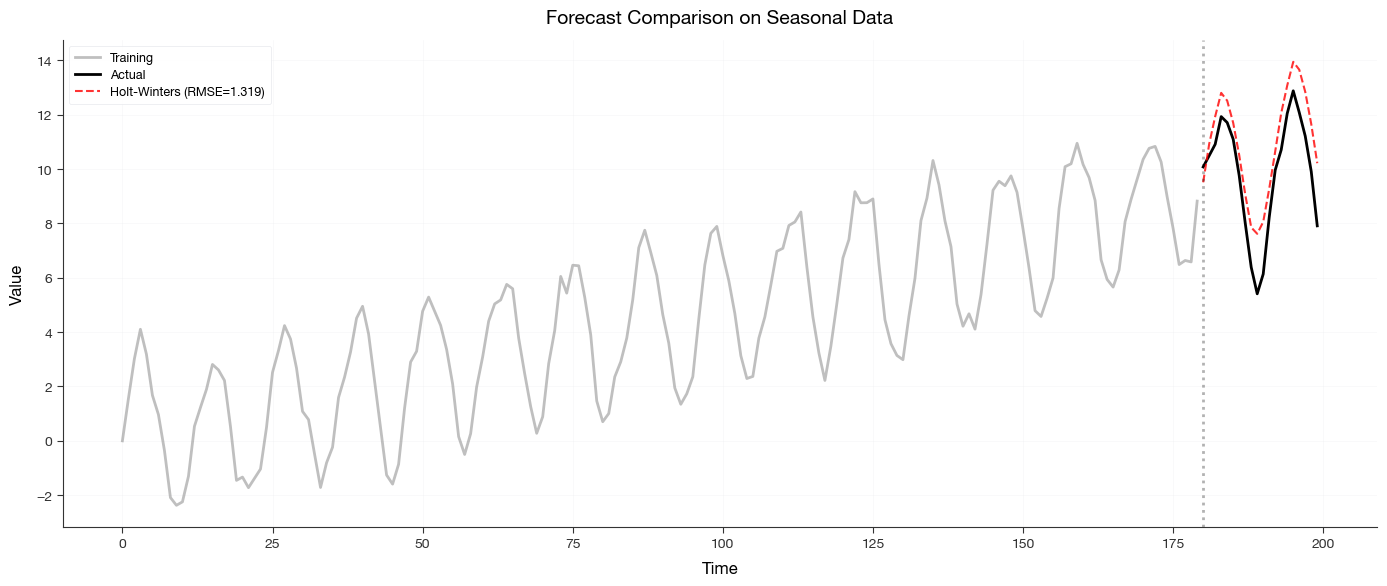

In [17]:
# Visualize seasonal forecasts
plt.figure(figsize=(14, 6))

plt.plot(t_train, y_train_seasonal, 'gray', alpha=0.5, label='Training')
plt.plot(t_test, y_test_seasonal, 'k-', linewidth=2, label='Actual')

colors = ['red', 'blue', 'green', 'orange', 'purple']
for (name, forecast), color in zip(forecasts.items(), colors):
    plt.plot(t_test, forecast, '--', color=color, linewidth=1.5,
             label=f"{name} (RMSE={results[name]['RMSE']:.3f})", alpha=0.8)

plt.axvline(x=train_size, color='k', linestyle=':', alpha=0.3)
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Forecast Comparison on Seasonal Data', fontweight='bold')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

## Choosing the Right Model

| Model | Best For | Handles Trend | Handles Seasonality |
|-------|----------|---------------|---------------------|
| **AR** | Simple autoregressive data | No | No |
| **MA** | Data with error correlation | No | No |
| **ARMA** | Stationary data | No | No |
| **ARIMA** | Non-stationary data | Yes (differencing) | No |
| **Exp. Smoothing** | Various patterns | Yes (Holt) | Yes (Holt-Winters) |
| **STL** | Understanding components | N/A (decomposition) | N/A (decomposition) |
| **Prophet** | Business forecasting | Yes (automatic) | Yes (automatic) |

### Tips

1. **Check stationarity first** — Use differencing if needed (ARIMA)
2. **Identify seasonality** — Use Holt-Winters or Prophet for seasonal data
3. **STL for exploration** — Understand your data structure before modeling
4. **Prophet for automatic** — When you need quick, reasonable forecasts
5. **ARIMA for precision** — When you can tune parameters carefully

## Summary

In this tutorial, you learned:

- **7 time series algorithms** available in TuiML
- The **ARIMA family** (AR, MA, ARMA, ARIMA) for different data patterns
- **Exponential Smoothing** variants for trend and seasonality
- **STL Decomposition** for understanding time series structure
- **Prophet** for automatic forecasting